<a href="https://colab.research.google.com/github/emanuelmejia/course_time_series_python/blob/main/L07-Modelos_ARIMA/notebooks/L07_3_ModelosSARIMA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pmdarima # Ojo: Después de la primera instalación se puede comentar esta línea

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pmdarima import auto_arima
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [2]:
# Subir archivo co2.csv
from google.colab import files
files.upload()

Saving co2.csv to co2 (9).csv


{'co2 (9).csv': b'"x"\r\n315.42\r\n316.31\r\n316.5\r\n317.56\r\n318.13\r\n318\r\n316.39\r\n314.65\r\n313.68\r\n313.18\r\n314.66\r\n315.43\r\n316.27\r\n316.81\r\n317.42\r\n318.87\r\n319.87\r\n319.43\r\n318.01\r\n315.74\r\n314\r\n313.68\r\n314.84\r\n316.03\r\n316.73\r\n317.54\r\n318.38\r\n319.31\r\n320.42\r\n319.61\r\n318.42\r\n316.63\r\n314.83\r\n315.16\r\n315.94\r\n316.85\r\n317.78\r\n318.4\r\n319.53\r\n320.42\r\n320.85\r\n320.45\r\n319.45\r\n317.25\r\n316.11\r\n315.27\r\n316.53\r\n317.53\r\n318.58\r\n318.92\r\n319.7\r\n321.22\r\n322.08\r\n321.31\r\n319.58\r\n317.61\r\n316.05\r\n315.83\r\n316.91\r\n318.2\r\n319.41\r\n320.07\r\n320.74\r\n321.4\r\n322.06\r\n321.73\r\n320.27\r\n318.54\r\n316.54\r\n316.71\r\n317.53\r\n318.55\r\n319.27\r\n320.28\r\n320.73\r\n321.97\r\n322\r\n321.71\r\n321.05\r\n318.71\r\n317.66\r\n317.14\r\n318.7\r\n319.25\r\n320.46\r\n321.43\r\n322.23\r\n323.54\r\n323.91\r\n323.59\r\n322.24\r\n320.2\r\n318.48\r\n317.94\r\n319.63\r\n320.87\r\n322.17\r\n322.34\r\n322.88\r\n3

In [3]:
df = pd.read_csv('/content/co2.csv')
df.head()

,x
0,315.42
1,316.31
2,316.50
3,317.56
4,318.13


In [4]:
df['Fecha'] = pd.period_range(start='1959-01', periods=len(df), freq='M')
df = df.set_index('Fecha')
df.index = df.index.to_timestamp()
df.head()

,x
Fecha,
1959-01-01,315.42
1959-02-01,316.31
1959-03-01,316.50
1959-04-01,317.56
1959-05-01,318.13


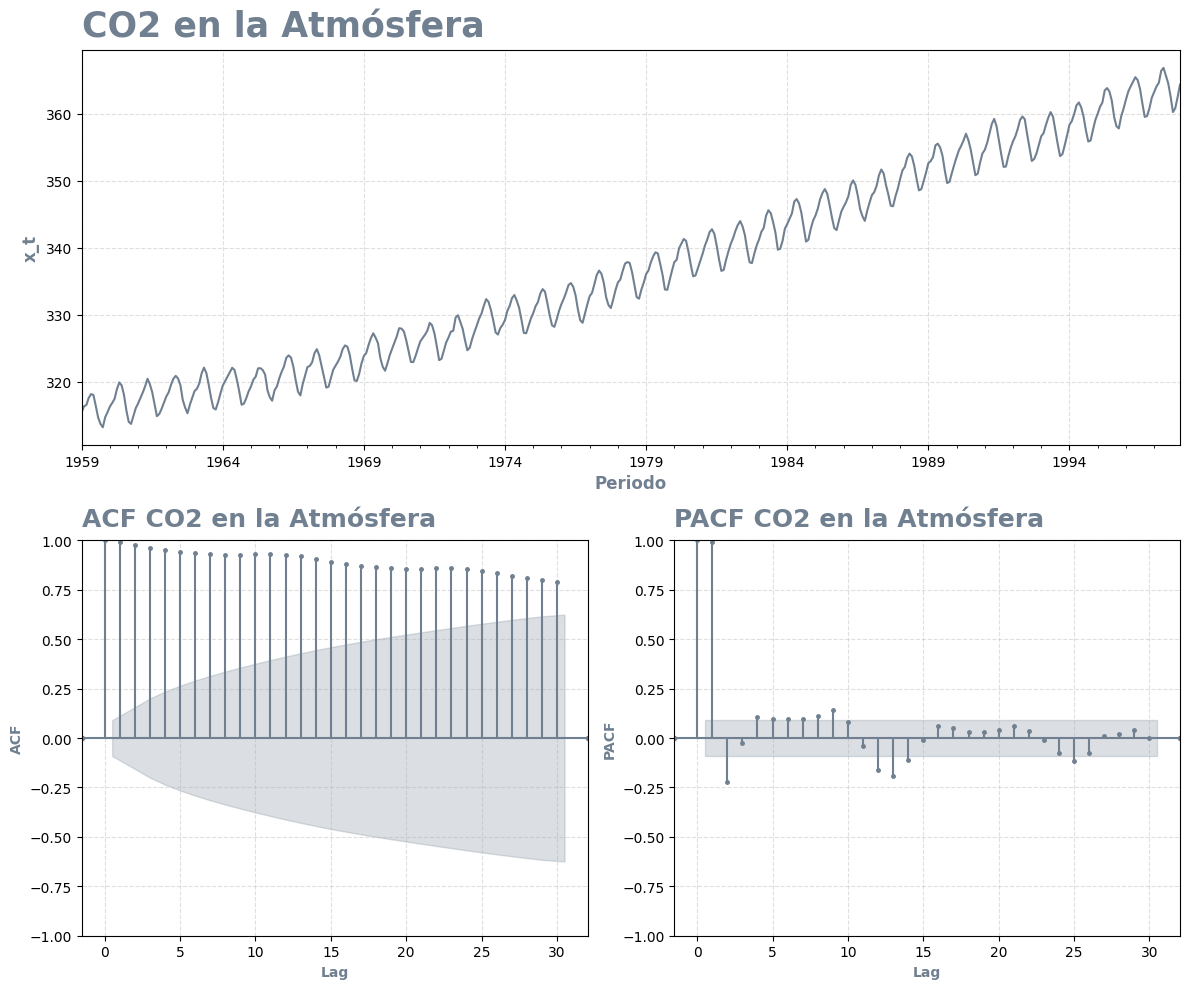

In [5]:
graphColor = 'slategray'
columna = 'x'
nombre = 'CO2 en la Atmósfera'

# Crear nuestra figura con un GridSpec para acomodar los gráficos
fig = plt.figure(figsize=(12, 10)) # Tamaño de toda la figura
gs = fig.add_gridspec(2, 2) # Enrejado de 2 filas y 2 columnas

# Gráfico superior ocupando fila completa
ax0 = fig.add_subplot(gs[0, :]) # Subgráfico en la primera fila abarcando todas las columnas
df[columna].plot(color = graphColor)
ax0.set_title(nombre, loc='left', color = graphColor, fontweight = 'bold', size = 25,  pad=10)
ax0.set_xlabel('Periodo', color = graphColor, fontweight = 'bold', size=12,)
ax0.set_ylabel('x_t', color = graphColor, fontweight = 'bold', size = 12)
ax0.grid(True, linestyle='--', alpha=0.4)

# Gráfico inferior izquierdo (ACF)
ax1 = fig.add_subplot(gs[1, 0]) # Subgráfico en la segunda fila primera columna
plot_acf(df[columna], lags=30, marker = '.', title= '', ax=ax1, # OJO con el parámetro ax
         color=graphColor, vlines_kwargs={"colors": graphColor})
# Cambio de color al intervalo de confianza
ciACF = ax1.collections[1]
ciACF.set_color(graphColor)
ax1.set_title('ACF ' + nombre, loc='left', color = graphColor, fontweight = 'bold', size = 18,  pad=10)
ax1.set_xlabel('Lag', color = graphColor, fontweight = 'bold')
ax1.set_ylabel('ACF', color = graphColor, fontweight = 'bold')
ax1.grid(True, linestyle='--', alpha=0.4)

# Gráfico inferior derecho (PACF)
ax2 = fig.add_subplot(gs[1, 1])  # Subgráfico en la segunda fila segunda columna
plot_pacf(df[columna], lags=30, marker = '.', title= '', ax=ax2,  # OJO con el parámetro ax
         color=graphColor, vlines_kwargs={"colors": graphColor})
# Cambio de color al intervalo de confianza
ciACF = ax2.collections[1]
ciACF.set_color(graphColor)
ax2.set_title('PACF ' + nombre, loc='left', color = graphColor, fontweight = 'bold', size = 18,  pad=10)
ax2.set_xlabel('Lag', color = graphColor, fontweight = 'bold')
ax2.set_ylabel('PACF', color = graphColor, fontweight = 'bold')
ax2.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout() # Prevenir traslape de etiquetas y títulos
plt.show()

In [6]:
# Ajuste de un modelo ARIMA automático con p, q de 1 a 5
# Si no se coloca orden para d, la función lo encuentra
arima_model_co2 = auto_arima(df['x'],
                       start_p=1, max_p=5,
                       start_q=1, max_q=5,
                       information_criterion = 'bic',
                       stepwise = True, # Prueba con algoritmo stepwise
                       with_intercept = True, # Que incluya un intercepto
                       trace = True, # Visualizar los modelos probados
                       # Parámetros NO utilizados en este momento:
                       seasonal=False,
                       D=0
                      )

print(arima_model_co2.summary())

Performing stepwise search to minimize bic
 ARIMA(1,1,1)(0,0,0)[0] intercept   : BIC=1132.710, Time=0.58 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : BIC=1511.884, Time=0.12 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : BIC=1196.150, Time=0.27 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : BIC=1228.006, Time=1.53 sec
 ARIMA(0,1,0)(0,0,0)[0]             : BIC=1509.253, Time=0.12 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : BIC=904.202, Time=2.25 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : BIC=1065.461, Time=0.41 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : BIC=910.061, Time=2.91 sec
 ARIMA(2,1,2)(0,0,0)[0] intercept   : BIC=909.958, Time=1.83 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : BIC=1099.427, Time=0.68 sec
 ARIMA(3,1,0)(0,0,0)[0] intercept   : BIC=1030.058, Time=0.83 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : BIC=916.478, Time=5.03 sec
 ARIMA(2,1,1)(0,0,0)[0]             : BIC=958.246, Time=1.22 sec

Best model:  ARIMA(2,1,1)(0,0,0)[0] intercept
Total fit time: 17.815 seconds
                          

In [7]:
# Obtener valores ajustados y predicciones
modelo = arima_model_co2
pasos = 340
nombreSerie = 'CO2 en la Atmósfera'
nombreModelo = 'ARIMA (Auto)'

# Obtener los valores ajustados a los datos históricos
valoresAjuste = modelo.fittedvalues()

# Excluir el primer valor del ajuste (estableciéndolo a NaN)
valoresAjuste.iloc[0] = np.nan

# Generar predicciones con intervalos de confianza al 95%
forecast, intConf = modelo.predict(n_periods=pasos, return_conf_int=True)
dfForArima = pd.DataFrame({
    'forecast': forecast,
    'cotaInf': intConf[:, 0],
    'cotaSup': intConf[:, 1]
})

print(valoresAjuste.head())
dfForArima.head()

Fecha
1959-01-01           NaN
1959-02-01    315.525755
1959-03-01    316.969030
1959-04-01    316.292731
1959-05-01    318.241945
Freq: MS, dtype: float64


,forecast,cotaInf,cotaSup
1998-01-01,365.933338,364.729429,367.137246
1998-02-01,366.856306,364.559477,369.153134
1998-03-01,366.958348,363.850307,370.066389
1998-04-01,366.359527,362.833665,369.885389
1998-05-01,365.374901,361.740612,369.009189


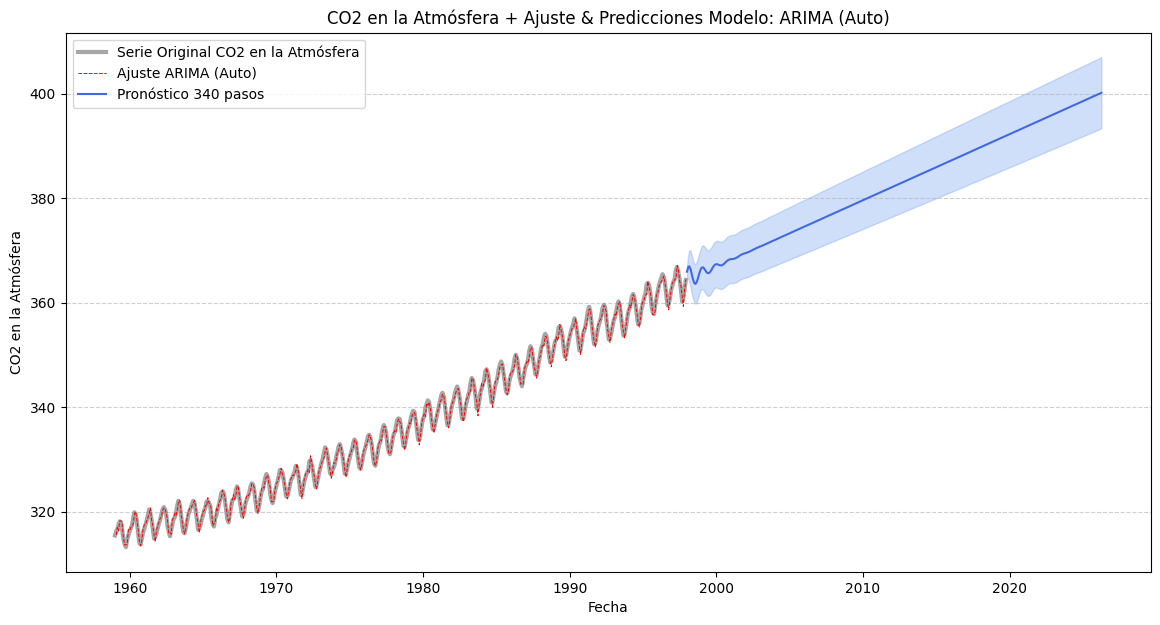

In [8]:
plt.figure(figsize=(14, 7))
# Gráfico Serie Original
plt.plot(df.index, df['x'], label='Serie Original ' + nombreSerie, color = 'gray', lw = 3, alpha = 0.7)
# Gráfico de Valores ajustados
plt.plot(df.index, valoresAjuste, label='Ajuste ' + nombreModelo, color = 'red', linestyle='--', lw = 0.7)
# Gráfico Pronóstico puntual
plt.plot(dfForArima.index, dfForArima['forecast'], label='Pronóstico ' + str(pasos) + ' pasos', color='royalblue')
# Gráfico Intervalos de confianza
plt.fill_between(dfForArima.index, dfForArima['cotaInf'], dfForArima['cotaSup'], color='cornflowerblue', alpha=0.3)

plt.title(nombreSerie + ' + Ajuste & Predicciones Modelo: ' + nombreModelo)
plt.xlabel('Fecha')
plt.ylabel(nombreSerie)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

## **Modelo SARIMA**

In [9]:
# Ajuste de un modelo SARIMA automático con p, q, P, Q de 0 a 5
# Si no se coloca orden para d, D la función los encuentra
sarima_model_co2 = auto_arima(df['x'],
                              start_p=1, max_p=5,
                              start_q=1, max_q=5,
                              information_criterion = 'aic',
                              stepwise = True, # Prueba con algoritmo stepwise
                              with_intercept = True, # Que incluya un intercepto
                              trace = True, # Visualizar los modelos probados
                              # Parámetros de estacionalidad
                              seasonal=True,
                              m = 12,
                              start_P=1, max_P=5,
                              start_Q=1, max_Q=5
                              )

print(sarima_model_co2.summary())

Performing stepwise search to minimize aic
 ARIMA(1,1,1)(1,1,1)[12] intercept   : AIC=179.223, Time=6.79 sec
 ARIMA(0,1,0)(0,1,0)[12] intercept   : AIC=443.981, Time=0.14 sec
 ARIMA(1,1,0)(1,1,0)[12] intercept   : AIC=307.708, Time=1.06 sec
 ARIMA(0,1,1)(0,1,1)[12] intercept   : AIC=178.228, Time=3.52 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=441.999, Time=0.12 sec
 ARIMA(0,1,1)(0,1,0)[12] intercept   : AIC=395.783, Time=0.71 sec
 ARIMA(0,1,1)(1,1,1)[12] intercept   : AIC=179.989, Time=3.07 sec
 ARIMA(0,1,1)(0,1,2)[12] intercept   : AIC=179.945, Time=6.26 sec
 ARIMA(0,1,1)(1,1,0)[12] intercept   : AIC=301.242, Time=0.76 sec
 ARIMA(0,1,1)(1,1,2)[12] intercept   : AIC=181.249, Time=9.99 sec
 ARIMA(0,1,0)(0,1,1)[12] intercept   : AIC=inf, Time=1.28 sec
 ARIMA(1,1,1)(0,1,1)[12] intercept   : AIC=177.559, Time=3.04 sec
 ARIMA(1,1,1)(0,1,0)[12] intercept   : AIC=394.690, Time=0.92 sec
 ARIMA(1,1,1)(0,1,2)[12] intercept   : AIC=179.154, Time=10.53 sec
 ARIMA(1,1,1)(1,1,0)[12] intercept  

In [10]:
# Obtener valores ajustados y predicciones
modelo = sarima_model_co2
pasos = 340
nombreSerie = 'CO2 en la Atmósfera'
nombreModelo = 'SARIMA (Auto)'

# Obtener los valores ajustados a los datos históricos
valoresAjuste = modelo.fittedvalues()

# Excluir el primer valor del ajuste (estableciéndolo a NaN)
valoresAjuste.iloc[0:13] = np.nan

# Generar predicciones con intervalos de confianza al 95%
forecast, intConf = modelo.predict(n_periods=pasos, return_conf_int=True)
dfForSarima = pd.DataFrame({
    'forecast': forecast,
    'cotaInf': intConf[:, 0],
    'cotaSup': intConf[:, 1]
})

print(valoresAjuste.head())
dfForSarima.head()

Fecha
1959-01-01   NaN
1959-02-01   NaN
1959-03-01   NaN
1959-04-01   NaN
1959-05-01   NaN
Freq: MS, dtype: float64


,forecast,cotaInf,cotaSup
1998-01-01,365.219969,364.661978,365.777959
1998-02-01,366.040156,365.373131,366.707180
1998-03-01,366.883263,366.130856,367.635670
1998-04-01,368.220148,367.403248,369.037047
1998-05-01,368.792426,367.921068,369.663784


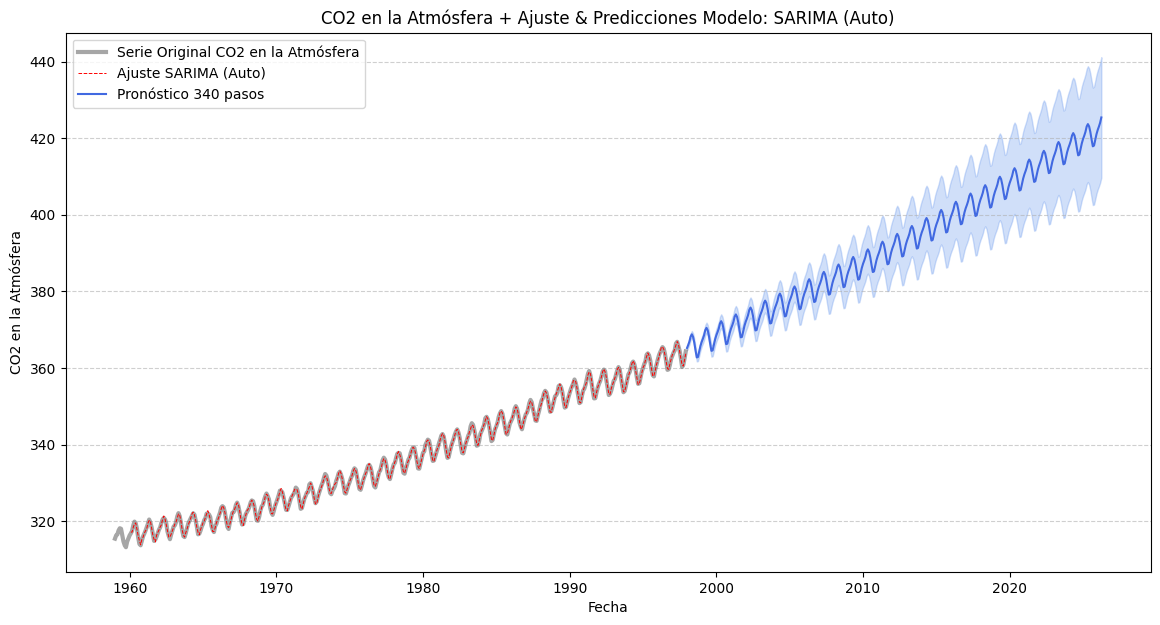

In [11]:
plt.figure(figsize=(14, 7))
# Gráfico Serie Original
plt.plot(df.index, df['x'], label='Serie Original ' + nombreSerie, color = 'gray', lw = 3, alpha = 0.7)
# Gráfico de Valores ajustados
plt.plot(df.index, valoresAjuste, label='Ajuste ' + nombreModelo, color = 'red', linestyle='--', lw = 0.7)
# Gráfico Pronóstico puntual
plt.plot(dfForSarima.index, dfForSarima['forecast'], label='Pronóstico ' + str(pasos) + ' pasos', color='royalblue')
# Gráfico Intervalos de confianza
plt.fill_between(dfForSarima.index, dfForSarima['cotaInf'], dfForSarima['cotaSup'], color='cornflowerblue', alpha=0.3)

plt.title(nombreSerie + ' + Ajuste & Predicciones Modelo: ' + nombreModelo)
plt.xlabel('Fecha')
plt.ylabel(nombreSerie)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

## **Modelo Manual**

In [12]:
# Aplicando directamente un modelo SARIMA(1,1,3)(2,1,2)[12]
sarima_model = SARIMAX(df['x'],
                       order=(1, 1, 3),
                       seasonal_order=(2, 1, 2, 12),
                       trend='c') # Incluir intercepto

sarima_model_manual = sarima_model.fit(maxiter=1000) # Número de iteraciones para ayudar con la convergencia
print(sarima_model_manual.summary())

                                        SARIMAX Results                                        
Dep. Variable:                                       x   No. Observations:                  468
Model:             SARIMAX(1, 1, 3)x(2, 1, [1, 2], 12)   Log Likelihood                 -80.778
Date:                                 Sat, 27 Jun 2026   AIC                            181.555
Time:                                         06:13:27   BIC                            222.758
Sample:                                     01-01-1959   HQIC                           197.788
                                          - 12-01-1997                                         
Covariance Type:                                   opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0018      0.002      1.022      0.307      -0.002       0

In [13]:
# Obtener valores ajustados y predicciones
modelo = sarima_model_manual
pasos = 340
nombreSerie = 'CO2 en la Atmósfera'
nombreModelo = 'SARIMA (Manual)'

# Obtener los valores ajustados a los datos históricos
valoresAjuste = modelo.fittedvalues

# Excluir el primer valor del ajuste (estableciéndolo a NaN)
valoresAjuste.iloc[0:13] = np.nan

# Generar predicciones con intervalos de confianza al 95%
prediction_results = modelo.get_forecast(steps=pasos)
forecast = prediction_results.predicted_mean
conf_intervals = prediction_results.conf_int(alpha=0.05)
intConf = conf_intervals.values

dfForSarimaMan = pd.DataFrame({
    'forecast': forecast,
    'cotaInf': intConf[:, 0],
    'cotaSup': intConf[:, 1]
})

print(valoresAjuste.head())
dfForSarimaMan.head()

Fecha
1959-01-01   NaN
1959-02-01   NaN
1959-03-01   NaN
1959-04-01   NaN
1959-05-01   NaN
Freq: MS, dtype: float64


,forecast,cotaInf,cotaSup
1998-01-01,365.191587,364.635719,365.747455
1998-02-01,365.971817,365.306035,366.637598
1998-03-01,366.784960,366.032177,367.537743
1998-04-01,368.197324,367.386186,369.008462
1998-05-01,368.759177,367.899282,369.619072


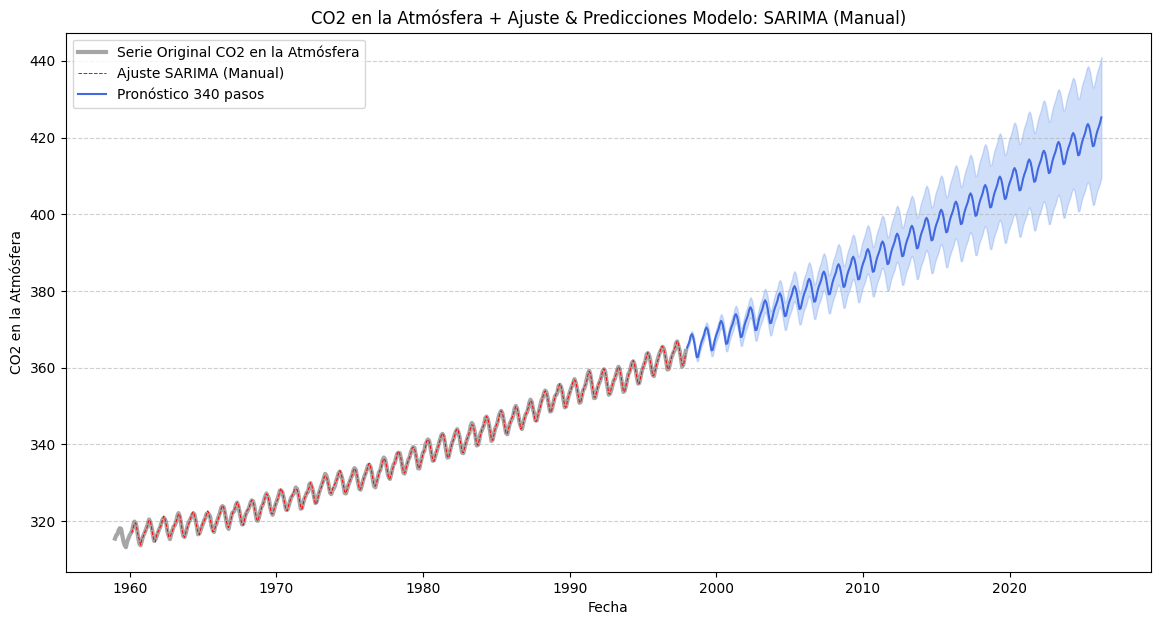

In [14]:
plt.figure(figsize=(14, 7))
# Gráfico Serie Original
plt.plot(df.index, df['x'], label='Serie Original ' + nombreSerie, color = 'gray', lw = 3, alpha = 0.7)
# Gráfico de Valores ajustados
plt.plot(df.index, valoresAjuste, label='Ajuste ' + nombreModelo, color = 'red', linestyle='--', lw = 0.7)
# Gráfico Pronóstico puntual
plt.plot(dfForSarimaMan.index, dfForSarimaMan['forecast'], label='Pronóstico ' + str(pasos) + ' pasos', color='royalblue')
# Gráfico Intervalos de confianza
plt.fill_between(dfForSarimaMan.index, dfForSarimaMan['cotaInf'], dfForSarimaMan['cotaSup'], color='cornflowerblue', alpha=0.3)

plt.title(nombreSerie + ' + Ajuste & Predicciones Modelo: ' + nombreModelo)
plt.xlabel('Fecha')
plt.ylabel(nombreSerie)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

## **Comparando con Datos Actuales**

In [15]:
# Datos actualizados
url = 'https://gml.noaa.gov/webdata/ccgg/trends/co2/co2_weekly_mlo.csv'
dfNuevoCO2 = pd.read_csv(url, skiprows=35)
dfNuevoCO2.head()

,year,month,day,decimal,average,ndays,1 year ago,10 years ago,increase since 1800
0,1974,5,19,1974.3795,333.37,5,-999.99,-999.99,50.40
1,1974,5,26,1974.3986,332.95,6,-999.99,-999.99,50.06
2,1974,6,2,1974.4178,332.35,5,-999.99,-999.99,49.60
3,1974,6,9,1974.4370,332.20,7,-999.99,-999.99,49.65
4,1974,6,16,1974.4562,332.37,7,-999.99,-999.99,50.06


In [16]:
# Elimina las filas con valores inválidos
dfNuevoCO2 = dfNuevoCO2[dfNuevoCO2['average'] != -999.99].copy()

# Crea una columna 'Fecha' a partir de las columnas existentes para el índice
dfNuevoCO2['Fecha'] = pd.to_datetime(dfNuevoCO2[['year', 'month', 'day']])
dfNuevoCO2 = dfNuevoCO2.set_index('Fecha')

# Columna que usaremos como ppm de CO2
dfNuevoCO2 = dfNuevoCO2.rename(columns={'average': 'ppm'})

# Descartar columnas que no nos interesan
dfNuevoCO2 = dfNuevoCO2[['ppm']]

dfNuevoCO2.head()

,ppm
Fecha,
1974-05-19,333.37
1974-05-26,332.95
1974-06-02,332.35
1974-06-09,332.20
1974-06-16,332.37


In [17]:
inicioPronostico = df.index.max() + pd.DateOffset(months=1) # Calcula la primera fecha del período de pronóstico, un mes después del último dato en 'df'

dfNuevoMensual = dfNuevoCO2['ppm'].resample('MS').mean().to_frame() # Remuestrea los datos diarios de 'dfNuevoCO2' a una frecuencia mensual ('MS') y calcula la media, convirtiéndolo a un DataFrame
dfNuevoMensual = dfNuevoMensual[dfNuevoMensual.index >= inicioPronostico] # Filtra el DataFrame mensual para incluir solo las fechas a partir del 'inicioPronostico'

dfNuevoMensual.head() # Muestra las primeras filas del DataFrame mensual filtrado

,ppm
Fecha,
1998-01-01,365.3950
1998-02-01,366.1050
1998-03-01,367.5680
1998-04-01,368.8125
1998-05-01,369.5700


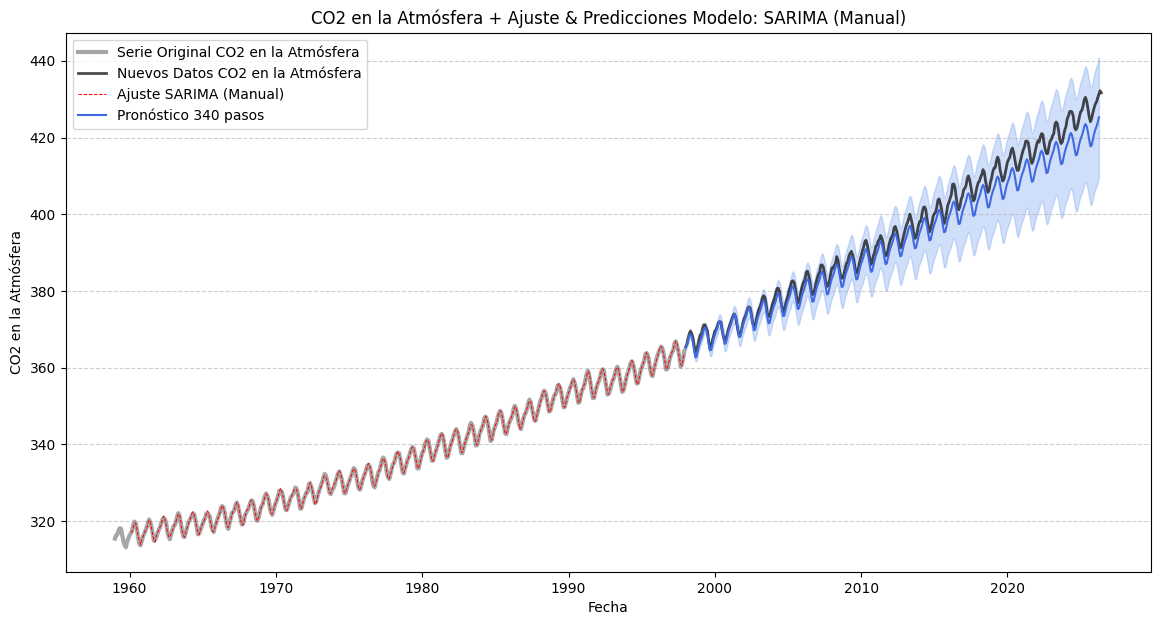

In [18]:
plt.figure(figsize=(14, 7))
# Gráfico Serie Original
plt.plot(df.index, df['x'], label='Serie Original ' + nombreSerie, color = 'gray', lw = 3, alpha = 0.7)
# Gráfico Nuevos valores
plt.plot(dfNuevoMensual.index, dfNuevoMensual['ppm'], label='Nuevos Datos ' + nombreSerie, color = 'black', lw = 2, alpha = 0.7)
# Gráfico de Valores ajustados
plt.plot(df.index, valoresAjuste, label='Ajuste ' + nombreModelo, color = 'red', linestyle='--', lw = 0.7)
# Gráfico Pronóstico puntual
plt.plot(dfForSarimaMan.index, dfForSarimaMan['forecast'], label='Pronóstico ' + str(pasos) + ' pasos', color='royalblue')
# Gráfico Intervalos de confianza
plt.fill_between(dfForSarimaMan.index, dfForSarimaMan['cotaInf'], dfForSarimaMan['cotaSup'], color='cornflowerblue', alpha=0.3)

plt.title(nombreSerie + ' + Ajuste & Predicciones Modelo: ' + nombreModelo)
plt.xlabel('Fecha')
plt.ylabel(nombreSerie)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

## **Métricas de Precisión de Pronósticos**

In [19]:
def metricasPrecision(real, pronostico, trainData, estacionalidad=12):
      resultados = {}

      # ME - Mean Error
      resultados['ME'] = np.mean(pronostico - real)

      # MAE - Mean Absolute Error
      resultados['MAE'] = mean_absolute_error(real, pronostico)

      # MSE - Mean Squared Error
      resultados['MSE'] = mean_squared_error(real, pronostico)

      # RMSE - Root Mean Squared Error
      resultados['RMSE'] = np.sqrt(mean_squared_error(real, pronostico))

      # Preparar para MPE y MAPE: manejar la división por cero
      # Reemplazar 0s con NaN para evitar la división por cero, luego filtrar NaNs
      realSinCero = real.replace(0, np.nan)
      realSinCero = realSinCero[realSinCero.notna()]
      pronosticoSinCero = pronostico[realSinCero.notna()]

      # MPE - Mean Percentage Error
      if len(realSinCero) > 0:
          resultados['MPE'] = np.mean(((realSinCero - pronosticoSinCero) / realSinCero)) * 100
      else:
          resultados['MPE'] = np.nan

      # MAPE - Mean Absolute Percentage Error
      if len(realSinCero) > 0:
          resultados['MAPE'] = np.mean(np.abs((realSinCero - pronosticoSinCero) / realSinCero)) * 100
      else:
          resultados['MAPE'] = np.nan

      # Para MASE y RMSSE, necesitamos calcular el factor de escala basado en naive
      # trainData es df['x']

      if len(trainData) > estacionalidad:
          patronEstacional = trainData.iloc[-estacionalidad:]
          pasos = len(real)
          naive = list(patronEstacional) * (pasos // estacionalidad) + list(patronEstacional)[0:(pasos % estacionalidad)]

          # Denominador para MASE
          MAENaive = mean_absolute_error(real, naive)

          # Denominador para RMSE
          RMSENaive = np.sqrt(mean_squared_error(real, naive))

          # 6. Error Absoluto Escalonado Medio (MASE)
          if MAENaive > 0:
              resultados['MASE'] = resultados['MAE'] / MAENaive
          else:
              resultados['MASE'] = np.inf if resultados['MAE'] > 0 else 0

          # 7. Raíz del Error Cuadrático Medio Escalonado (RMSSE)
          if RMSENaive > 0:
              resultados['RMSSE'] = resultados['RMSE'] / RMSENaive
          else:
              resultados['RMSSE'] = np.inf if resultados['RMSE'] > 0 else 0
      else:
          resultados['MASE'] = np.nan
          resultados['RMSSE'] = np.nan

      return resultados

In [20]:
# --- Calcular y mostrar métricas para cada modelo ---
dfReal = dfNuevoMensual.iloc[:pasos] # Seleccionar el mismo número de pasos para datos reales y pronósticos
resultados_metricas = {}

resultados_metricas['ARIMA Auto'] = metricasPrecision(dfReal['ppm'], dfForArima['forecast'], df['x'])
resultados_metricas['SARIMA Auto'] = metricasPrecision(dfReal['ppm'], dfForSarima['forecast'], df['x'])
resultados_metricas['SARIMA Manual'] = metricasPrecision(dfReal['ppm'], dfForSarimaMan['forecast'], df['x'])

# Convertir a DataFrame para una mejor visualización
df_metricas = pd.DataFrame.from_dict(resultados_metricas, orient='index')
df_metricas.round(4)

,ME,MAE,MSE,RMSE,MPE,MAPE,MASE,RMSSE
ARIMA Auto,-12.7349,12.7737,233.0568,15.2662,3.1327,3.1433,0.4091,0.4210
SARIMA Auto,-2.7799,2.7858,11.0407,3.3228,0.6851,0.6867,0.0892,0.0916
SARIMA Manual,-2.8697,2.8750,11.7251,3.4242,0.7073,0.7087,0.0921,0.0944


¿Cuál tiene mejor desempeño?

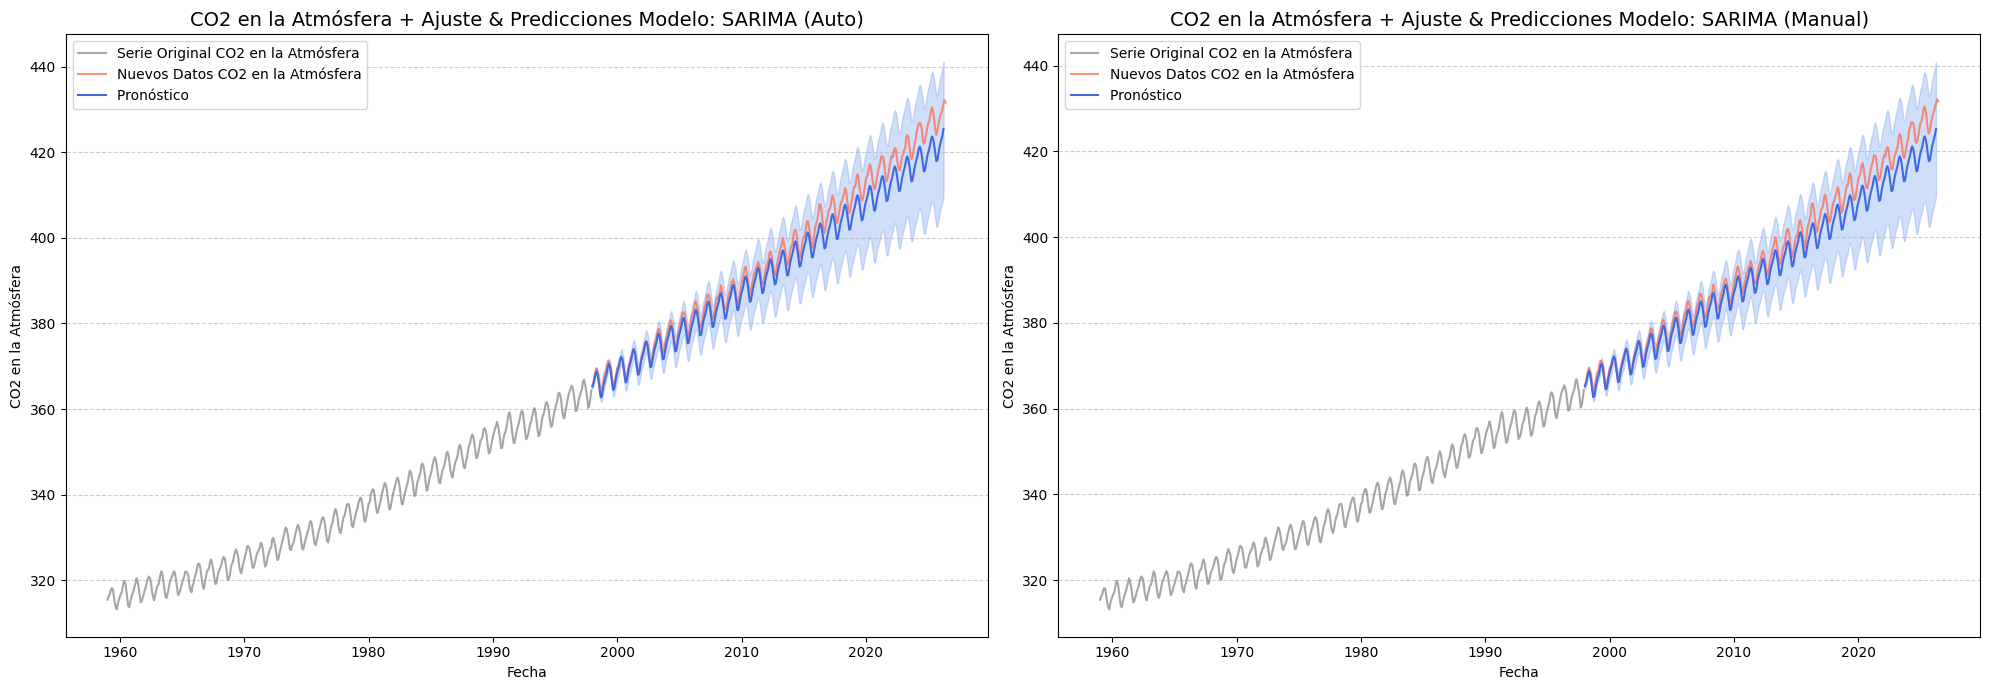

In [21]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 7))

# --- Gráfico SARIMA (Auto) ---
ax1.plot(df.index, df['x'], label='Serie Original ' + nombreSerie, color='gray', alpha=0.7)
ax1.plot(dfNuevoMensual.index, dfNuevoMensual['ppm'], label='Nuevos Datos ' + nombreSerie, color='tomato', lw=1.5, alpha=0.7)
ax1.plot(dfForSarima.index, dfForSarima['forecast'], label='Pronóstico ', color='royalblue')
ax1.fill_between(dfForSarima.index, dfForSarima['cotaInf'], dfForSarima['cotaSup'], color='cornflowerblue', alpha=0.3)
ax1.set_title(nombreSerie + ' + Ajuste & Predicciones Modelo: SARIMA (Auto)', fontsize=14)
ax1.set_xlabel('Fecha')
ax1.set_ylabel(nombreSerie)
ax1.legend()
ax1.grid(axis='y', linestyle='--', alpha=0.6)

# --- Gráfico SARIMA (Manual) ---
ax2.plot(df.index, df['x'], label='Serie Original ' + nombreSerie, color='gray', alpha=0.7)
ax2.plot(dfNuevoMensual.index, dfNuevoMensual['ppm'], label='Nuevos Datos ' + nombreSerie, color='tomato', lw=1.5, alpha=0.7)
ax2.plot(dfForSarimaMan.index, dfForSarimaMan['forecast'], label='Pronóstico ', color='royalblue')
ax2.fill_between(dfForSarimaMan.index, dfForSarimaMan['cotaInf'], dfForSarimaMan['cotaSup'], color='cornflowerblue', alpha=0.3)
ax2.set_title(nombreSerie + ' + Ajuste & Predicciones Modelo: SARIMA (Manual)', fontsize=14)
ax2.set_xlabel('Fecha')
ax2.set_ylabel(nombreSerie)
ax2.legend()
ax2.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()